<a href="https://colab.research.google.com/github/CaioAntonine/CaioAntonine_MVP_CEP/blob/main/Exerc%C3%ADcios_Cap_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Assumindo fração média não conforme (p_bar) = 0.0150

--- a) Limites do Gráfico de Controle ---
Linha Central (CL) = 0.0150
Limite Superior (UCL) = 0.0448
Limite Inferior Calculado = -0.0148 -> Ajustado (LCL) = 0.0000

--- b) Menor tamanho de amostra ---
O tamanho mínimo de amostra (n) deve ser > 591.00
Portanto, o menor tamanho inteiro é n = 591



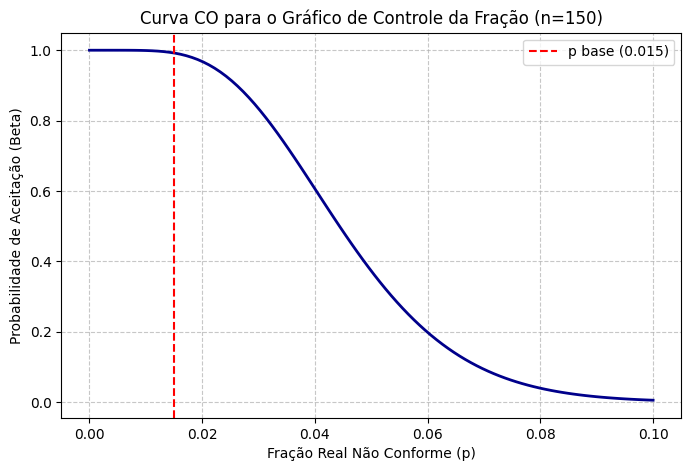

--- d) Probabilidade de detecção ---
Prob. de NÃO detectar a mudança (Beta) em uma amostra = 0.8340
Prob. de DETECTAR a mudança (1-Beta) em uma amostra = 0.1660
Probabilidade de detectar exatamente na 3ª amostra = 0.1155 (ou 11.55%)


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom
import math

n = 150 # Tamanho da amostra
m = 20  # Número de amostras (dias)

p_bar = 0.015

print(f"Assumindo fração média não conforme (p_bar) = {p_bar:.4f}\n")


std_dev = np.sqrt((p_bar * (1 - p_bar)) / n)

UCL = p_bar + 3 * std_dev
LCL = p_bar - 3 * std_dev

LCL_adj = max(0, LCL)

print("--- a) Limites do Gráfico de Controle ---")
print(f"Linha Central (CL) = {p_bar:.4f}")
print(f"Limite Superior (UCL) = {UCL:.4f}")
print(f"Limite Inferior Calculado = {LCL:.4f} -> Ajustado (LCL) = {LCL_adj:.4f}\n")



n_min = (9 * (1 - p_bar)) / p_bar
n_min_int = math.ceil(n_min)

print("--- b) Menor tamanho de amostra ---")
print(f"O tamanho mínimo de amostra (n) deve ser > {n_min:.2f}")
print(f"Portanto, o menor tamanho inteiro é n = {n_min_int}\n")

p_valores = np.linspace(0, 0.10, 100)

d_UCL = np.floor(UCL * n)
d_LCL = np.ceil(LCL_adj * n)

if d_LCL == 0:
    beta = binom.cdf(d_UCL, n, p_valores)
else:
    beta = binom.cdf(d_UCL, n, p_valores) - binom.cdf(d_LCL - 1, n, p_valores)

plt.figure(figsize=(8, 5))
plt.plot(p_valores, beta, lw=2, color='darkblue')
plt.title('Curva CO para o Gráfico de Controle da Fração (n=150)')
plt.xlabel('Fração Real Não Conforme (p)')
plt.ylabel('Probabilidade de Aceitação (Beta)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.axvline(x=p_bar, color='r', linestyle='--', label=f'p base ({p_bar})')
plt.legend()
plt.show()

p_novo = 0.03

if d_LCL == 0:
    beta_novo = binom.cdf(d_UCL, n, p_novo)
else:
    beta_novo = binom.cdf(d_UCL, n, p_novo) - binom.cdf(d_LCL - 1, n, p_novo)

prob_detectar = 1 - beta_novo

prob_terceira = (beta_novo ** 2) * prob_detectar

print("--- d) Probabilidade de detecção ---")
print(f"Prob. de NÃO detectar a mudança (Beta) em uma amostra = {beta_novo:.4f}")
print(f"Prob. de DETECTAR a mudança (1-Beta) em uma amostra = {prob_detectar:.4f}")
print(f"Probabilidade de detectar exatamente na 3ª amostra = {prob_terceira:.4f} (ou {prob_terceira*100:.2f}%)")

--- Dados Iniciais ---
Total de amostras (m): 20
Total de não conformidades encontradas: 50

--- a) Gráfico c (Número Total de Não Conformidades) ---
Linha Central (CL) = 2.5000
Limite Superior (UCL) = 7.2434
Limite Inferior Calculado = -2.2434 -> Ajustado (LCL) = 0.0000
Conclusão: O processo ESTÁ sob controlo estatístico. Nenhum valor diário ultrapassa o UCL (7.24) ou fica abaixo do LCL (0).

--- b) Gráfico u (Média de Não Conformidades por Unidade) ---
Considerando n = 1 (cada amostra é 1 unidade de 1000m):
Linha Central (CL) = 2.5000
Limite Superior (UCL) = 7.2434
Limite Inferior (LCL) = 0.0000
Nota: Como n = 1, a escala e os limites do gráfico u são exactamente iguais aos do gráfico c.



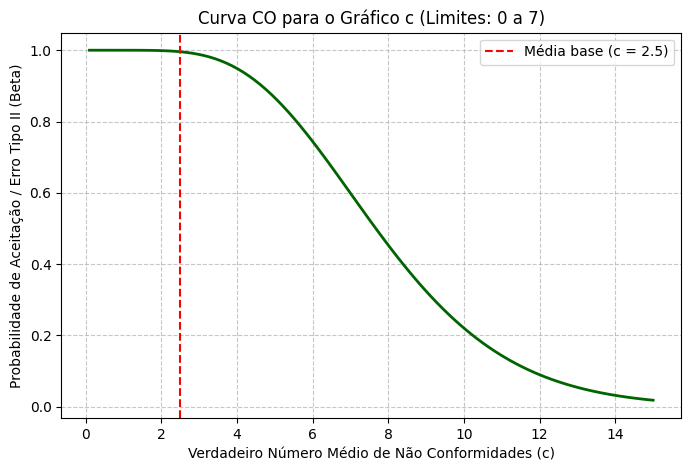

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

dados = [3, 2, 4, 2, 5, 2, 1, 2, 0, 5, 2, 4, 1, 3, 6, 0, 1, 2, 3, 2]
m = len(dados) # Total de amostras (dias) = 20
total_nc = sum(dados) # Soma total de não conformidades

print("--- Dados Iniciais ---")
print(f"Total de amostras (m): {m}")
print(f"Total de não conformidades encontradas: {total_nc}\n")


c_bar = total_nc / m

UCL_c = c_bar + 3 * np.sqrt(c_bar)
LCL_c = c_bar - 3 * np.sqrt(c_bar)


LCL_c_adj = max(0, LCL_c)

print("--- a) Gráfico c (Número Total de Não Conformidades) ---")
print(f"Linha Central (CL) = {c_bar:.4f}")
print(f"Limite Superior (UCL) = {UCL_c:.4f}")
print(f"Limite Inferior Calculado = {LCL_c:.4f} -> Ajustado (LCL) = {LCL_c_adj:.4f}")

fora_de_controlo = [i+1 for i, x in enumerate(dados) if x > UCL_c or x < LCL_c_adj]

if len(fora_de_controlo) == 0:
    print("Conclusão: O processo ESTÁ sob controlo estatístico. Nenhum valor diário ultrapassa o UCL (7.24) ou fica abaixo do LCL (0).\n")
else:
    print(f"Conclusão: O processo NÃO ESTÁ sob controlo. Pontos fora nos dias: {fora_de_controlo}\n")

n = 1
u_bar = total_nc / (m * n)

UCL_u = u_bar + 3 * np.sqrt(u_bar / n)
LCL_u = max(0, u_bar - 3 * np.sqrt(u_bar / n))

print("--- b) Gráfico u (Média de Não Conformidades por Unidade) ---")
print(f"Considerando n = 1 (cada amostra é 1 unidade de 1000m):")
print(f"Linha Central (CL) = {u_bar:.4f}")
print(f"Limite Superior (UCL) = {UCL_u:.4f}")
print(f"Limite Inferior (LCL) = {LCL_u:.4f}")
print("Nota: Como n = 1, a escala e os limites do gráfico u são exactamente iguais aos do gráfico c.\n")


c_valores = np.linspace(0.1, 15, 100)


limite_aceitacao = int(np.floor(UCL_c))

beta = poisson.cdf(limite_aceitacao, c_valores)

plt.figure(figsize=(8, 5))
plt.plot(c_valores, beta, lw=2, color='darkgreen')
plt.title('Curva CO para o Gráfico c (Limites: 0 a 7)')
plt.xlabel('Verdadeiro Número Médio de Não Conformidades (c)')
plt.ylabel('Probabilidade de Aceitação / Erro Tipo II (Beta)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.axvline(x=c_bar, color='red', linestyle='--', label=f'Média base (c = {c_bar})')
plt.legend()
plt.show()

In [8]:
import numpy as np
from scipy.stats import binom

print(" PARTE 1: Dados do Cabo de Telefone (Ex. 7.41)")

dados_cabos = [1, 1, 3, 7, 8, 10, 5, 13, 0, 19, 24, 6, 9, 11, 15, 8, 3, 6, 7, 4, 9, 20]
m = len(dados_cabos)

c_bar = sum(dados_cabos) / m
ucl_c = c_bar + 3 * np.sqrt(c_bar)
lcl_c = max(0, c_bar - 3 * np.sqrt(c_bar))

print(f"Linha Central (c_bar) = {c_bar:.4f}")
print(f"Limite Superior (UCL) = {ucl_c:.4f}")
print(f"Limite Inferior (LCL) = {lcl_c:.4f}")

fora_limites = [i+1 for i, x in enumerate(dados_cabos) if x > ucl_c or x < lcl_c]
if fora_limites:
    print(f"Atenção: Processo fora de controle nas amostras: {fora_limites}")
else:
    print("Processo sob controle estatístico.")

print(" PARTE 2: Probabilidade de Detecção de Mudança")

p_original = 0.02
n = 50
p_novo = 0.04

std_dev = np.sqrt((p_original * (1 - p_original)) / n)
UCL_p = p_original + 3 * std_dev
LCL_p = max(0, p_original - 3 * std_dev)

print(f"Limites do Gráfico p (n={n}, p={p_original}):")
print(f"UCL = {UCL_p:.4f} | LCL = {LCL_p:.4f}\n")

d_UCL = np.floor(UCL_p * n)

beta = binom.cdf(d_UCL, n, p_novo)

prob_detectar = 1 - beta

prob_dia_1 = prob_detectar
prob_dia_3 = (beta ** 2) * prob_detectar

print("--- Resultados das Probabilidades ---")
print(f"Prob. de NÃO detectar (Beta) = {beta:.4f}")
print(f"a) Prob. de detectar no PRIMEIRO dia = {prob_dia_1:.4f} (ou {prob_dia_1*100:.2f}%)")
print(f"b) Prob. de detectar no TERCEIRO dia = {prob_dia_3:.4f} (ou {prob_dia_3*100:.2f}%)")

 PARTE 1: Dados do Cabo de Telefone (Ex. 7.41)
Linha Central (c_bar) = 8.5909
Limite Superior (UCL) = 17.3840
Limite Inferior (LCL) = 0.0000
Atenção: Processo fora de controle nas amostras: [10, 11, 22]
 PARTE 2: Probabilidade de Detecção de Mudança
Limites do Gráfico p (n=50, p=0.02):
UCL = 0.0794 | LCL = 0.0000

--- Resultados das Probabilidades ---
Prob. de NÃO detectar (Beta) = 0.8609
a) Prob. de detectar no PRIMEIRO dia = 0.1391 (ou 13.91%)
b) Prob. de detectar no TERCEIRO dia = 0.1031 (ou 10.31%)


In [9]:
import numpy as np
from scipy.stats import poisson, norm

c_bar = 16
prob_inferior = 0.001
prob_superior = 0.999

LCL_poisson = poisson.ppf(prob_inferior, c_bar)
UCL_poisson = poisson.ppf(prob_superior, c_bar)

prob_real_LCL = poisson.cdf(LCL_poisson, c_bar)
prob_real_UCL = poisson.cdf(UCL_poisson, c_bar)

print(f"Limite Inferior de Probabilidade (LCL) = {int(LCL_poisson)}")
print(f" -> Probabilidade acumulada exata para <= {int(LCL_poisson)}: {prob_real_LCL:.5f}")
print(f"Limite Superior de Probabilidade (UCL) = {int(UCL_poisson)}")
print(f" -> Probabilidade acumulada exata para <= {int(UCL_poisson)}: {prob_real_UCL:.5f}\n")

desvio_padrao = np.sqrt(c_bar)

LCL_3sigma = c_bar - 3 * desvio_padrao
UCL_3sigma = c_bar + 3 * desvio_padrao

z_score = norm.ppf(0.999)
LCL_norm_exato = c_bar - z_score * desvio_padrao
UCL_norm_exato = c_bar + z_score * desvio_padrao

print("--- A) Limites Clássicos (3-sigma) ---")
print(f"LCL = 16 - 3*sqrt(16) = {LCL_3sigma:.2f}")
print(f"UCL = 16 + 3*sqrt(16) = {UCL_3sigma:.2f}\n")

print(f"--- B) Limites Normais com Z exato ({z_score:.4f}-sigma) ---")
print(f"LCL = 16 - {z_score:.4f}*sqrt(16) = {LCL_norm_exato:.2f}")
print(f"UCL = 16 + {z_score:.4f}*sqrt(16) = {UCL_norm_exato:.2f}\n")

print(" COMPARAÇÃO DOS RESULTADOS")
print(f"Poisson Exato : LCL = {int(LCL_poisson)} | UCL = {int(UCL_poisson)}")
print(f"Normal Clássico (3-sigma): LCL = {LCL_3sigma:.0f} | UCL = {UCL_3sigma:.0f}")

Limite Inferior de Probabilidade (LCL) = 5
 -> Probabilidade acumulada exata para <= 5: 0.00138
Limite Superior de Probabilidade (UCL) = 30
 -> Probabilidade acumulada exata para <= 30: 0.99943

--- A) Limites Clássicos (3-sigma) ---
LCL = 16 - 3*sqrt(16) = 4.00
UCL = 16 + 3*sqrt(16) = 28.00

--- B) Limites Normais com Z exato (3.0902-sigma) ---
LCL = 16 - 3.0902*sqrt(16) = 3.64
UCL = 16 + 3.0902*sqrt(16) = 28.36

 COMPARAÇÃO DOS RESULTADOS
Poisson Exato : LCL = 5 | UCL = 30
Normal Clássico (3-sigma): LCL = 4 | UCL = 28
